In [1]:
import codecs
import nltk
from nltk.tokenize import sent_tokenize

## Sentence Analysis

We perform an analysis on the lengths of sentences in the books. This is a quick
check to make sure that the sentence tokenizer is working as expected.

The main idea is that if we see lots of long sentences, it is not working.

In [2]:
import nltk
path = "/projectnb/scottml/punkt_cache/"
nltk.download('punkt', download_dir=path)
#nltk.download('punktab', download_dir=path)
nltk.data.path.append(path)

[nltk_data] Downloading package punkt to
[nltk_data]     /projectnb/scottml/punkt_cache/...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# Import the clean Blood Memory Text
#blood_memory_txt = "../scripts/data/clean/blood_memory_clean.txt"
blood_memory_txt = "/projectnb/scottml/seansal2/data/clean/blood_memory_clean.txt"
with codecs.open(blood_memory_txt, 'r', encoding='utf-8-sig') as file:
    clean_text = file.read()

In [4]:
# Use the nltk sentence tokenizer to split the full text into a list of sentences
sentences = sent_tokenize(clean_text)

In [5]:

def count_words(sentence):
    """
    Function to count words in a sentence.
    Input: sentence -> string
    Output: # words in a sentence -> int
    """
    return len(sentence.split())

# Use list comprehension to get sentence lengths (# of words in sentence)
sentence_lengths = [count_words(sentence) for sentence in sentences]

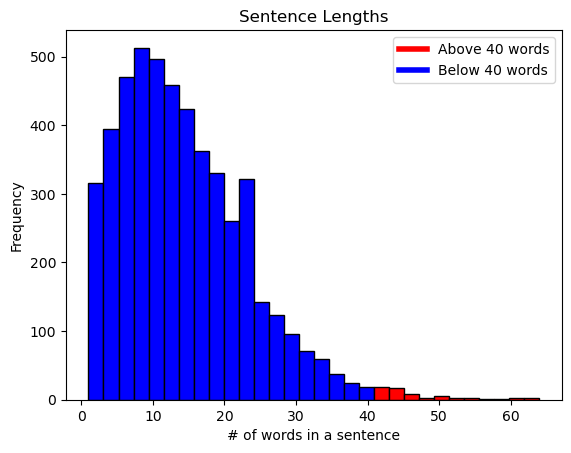

In [6]:
import matplotlib.pyplot as plt

# Histogram of sentence lengths

# Define a threshold
threshold = 40

# Create the histogram
counts, bins, patches = plt.hist(sentence_lengths, bins=30, edgecolor='black')

# Change the color of bars based on the threshold
for patch, left, right in zip(patches, bins[:-1], bins[1:]):
    if left >= threshold:
        patch.set_facecolor('red')
    else:
        patch.set_facecolor('blue')

# Add a legend
red_patch = plt.Line2D([0], [0], color='red', lw=4, label=f'Above {threshold} words')
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label=f'Below {threshold} words')
plt.legend(handles=[red_patch, blue_patch])

plt.xlabel('# of words in a sentence')
plt.ylabel('Frequency')
plt.title("Sentence Lengths")
plt.show()


In [7]:
import pandas as pd

# Create a dataframe where the columns are sentence lengths and the corresponding sentence
df = pd.DataFrame({"length": sentence_lengths, "sentence": sentences})

print(f"Median # words in a sentence {df['length'].median()}")

Median # words in a sentence 13.0


In [8]:
df.head(3)

,length,sentence
0,4,I am a dancer.
1,7,I believe that we learn by practice.
2,23,Whether it means to learn to dance by practici...


In [9]:
# Confirm correct text in a long sentence
long_sentences = df[df["length"] > 50]
long_sentences.head()
# Get row 1 sentence.
print(long_sentences["sentence"].iloc[0])

He took thousands and thousands and it is that legend that gives us the courage, the energy, and arrogance to go back into the studio knowing that while there is so little time to be born to the instant, you will work again among the many that you may once more be born as one.


## Creating a Dataset

We take the sentences and create a dataset object where they are stored. 
The dataset class is from the huggingface datasets package. This class has useful 
features, namely, 

- it stores our data, i.e., the sentences,
- it has built-in methods wihch can tokenize each sentence, and
- it can create train-test splits of the data.
 

In [10]:
import math
sentence = "My name is Sean, I'm a terrier"
words = sentence.split()  # Tokenize the sentence into words
n_words = len(words)
split_idx = math.ceil(n_words/2)  # Get halfway point

prompt = " ".join(words[:split_idx])  # First half as prompt
answer = " ".join(words[split_idx:])  # Second half as answer
prompt, answer

('My name is Sean,', "I'm a terrier")

In [11]:
import math 
def sentence_generator(sentences):
    """
    Generator function to yield a dictionary containing a sentence
    Input: list of sentences
    Yield: dictionary containing sentence
    """
    #Can we use word count from earlier?
    for sentence in sentences:
        words = sentence.split()  # Tokenize the sentence into words
        n_words = len(words)
        split_idx = math.ceil(n_words/2)  # Get halfway point
        
        prompt = " ".join(words[:split_idx])  # First half as prompt
        answer = " ".join(words[split_idx:])

        #we use yield to make this a generatorfnction
            #doesn't return all results at once, yield pauses funnction and returns/generates one dict. at a time
            #function resumes where it left off of
            #Why? Efficient memory ussage 
        yield {"text": prompt, "answer": answer}


In [23]:
from datasets import Dataset

# Create dataset variable
dataset = Dataset.from_generator(sentence_generator, gen_kwargs={"sentences": sentences})
#Create this, look at first entry 

In [24]:
dataset.to_csv('/projectnb/scottml/seansal2/data/datasets/blood_memory.csv')

Creating CSV from Arrow format: 100%|█████████████| 5/5 [00:00<00:00, 48.96ba/s]


387601

In [19]:
type(dataset)

datasets.arrow_dataset.Dataset

In [25]:
# Create train test split of the data
dataset = dataset.train_test_split(test_size=0.2, seed=2)
print(dataset["train"])
print(dataset["test"])

Dataset({
    features: ['text', 'answer'],
    num_rows: 3987
})
Dataset({
    features: ['text', 'answer'],
    num_rows: 997
})


In [26]:
dataset["train"][2]

{'text': 'Frances believed in me and without ever having seen me dance',
 'answer': 'signed a loan for one thousand dollars for my first concert.'}

In [22]:
type(dataset)

datasets.dataset_dict.DatasetDict

In [15]:
from transformers import AutoTokenizer, AutoModelForCausalLM
#Now we are setting up a tokenizer for use with Llama
MODEL = "meta-llama/Llama-2-7b-chat-hf"
CACHE_DIR = "../language_model"
import configparser
config = configparser.ConfigParser()
config.read('../scripts/marthabot.cfg')

def create_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(MODEL, 
                                              cache_dir = CACHE_DIR,
                                              access_token = config("Access").get("hf_token")) #add sean access token to file 
    return tokenizer

In [43]:
tokenizer = create_tokenizer()

tokenizer.add_special_tokens({'pad_token': '<pad>'})

# Load the model and resize token embeddings
model = AutoModelForCausalLM.from_pretrained(MODEL, 
                                             cache_dir = CACHE_DIR,)
model.resize_token_embeddings(len(tokenizer))

# Verify the pad token
print(f"Pad token: {tokenizer.pad_token}, ID: {tokenizer.pad_token_id}")

special_tokens = {
    "bos_token": tokenizer.bos_token,
    "eos_token": tokenizer.eos_token,
    "unk_token": tokenizer.unk_token,
    "sep_token": tokenizer.sep_token,
    "pad_token": tokenizer.pad_token,
    "cls_token": tokenizer.cls_token,
    "mask_token": tokenizer.mask_token,
    "additional_special_tokens": tokenizer.additional_special_tokens
}

# Print the special tokens
for token_name, token_value in special_tokens.items():
    print(f"{token_name}: {token_value}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Pad token: <pad>, ID: 32000
bos_token: <s>
eos_token: </s>
unk_token: <unk>
sep_token: None
pad_token: <pad>
cls_token: None
mask_token: None
additional_special_tokens: []


In [44]:
bos_token_id = tokenizer.bos_token_id
eos_token_id = tokenizer.eos_token_id

print(f"BOS token ID: {bos_token_id}")
print(f"EOS token ID: {eos_token_id}")
print(f"Pad token: {tokenizer.pad_token}, ID: {tokenizer.pad_token_id}")

BOS token ID: 1
EOS token ID: 2
Pad token: <pad>, ID: 32000


In [34]:
def preprocess_function(examples):
    # Tokenize the input text
    tokenized_inputs = tokenizer([" ".join(x) for x in examples["text"]],
                                 padding=True,
                                 truncation=True)

    # Copy input_ids to labels
    input_ids = tokenized_inputs["input_ids"]
    labels = input_ids.copy()
    
    # Shift labels to the right and add EOS token
    for i in range(len(labels)):
        labels[i] = labels[i][1:] + [tokenizer.eos_token_id]
    
    tokenized_inputs["labels"] = labels
    
    return tokenized_inputs

In [35]:
import os
NSLOTS = int(os.environ.get("NSLOTS", 1))
print(NSLOTS)
tokenized_dataset = dataset.map(preprocess_function, batched=True, num_proc=NSLOTS)

4


Map (num_proc=4):   0%|          | 0/3987 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


ValueError: Asking to pad but the tokenizer does not have a padding token. Please select a token to use as `pad_token` `(tokenizer.pad_token = tokenizer.eos_token e.g.)` or add a new pad token via `tokenizer.add_special_tokens({'pad_token': '[PAD]'})`.

In [30]:
print(tokenized_dataset["train"][0])

{'text': 'Nothing lets me think more clearly through a problem than reading and alternating between two mysteries at the same time.', 'input_ids': [1, 405, 288, 260, 298, 474, 302, 330, 259, 301, 321, 260, 269, 259, 286, 321, 259, 260, 298, 474, 302, 413, 259, 286, 288, 364, 321, 259, 274, 301, 321, 263, 364, 301, 343, 259, 260, 298, 364, 288, 318, 330, 298, 259, 263, 259, 282, 364, 288, 289, 301, 321, 286, 259, 260, 298, 263, 302, 259, 364, 321, 263, 270, 474, 302, 330, 259, 263, 302, 270, 259, 263, 301, 260, 321, 364, 302, 263, 260, 474, 302, 330, 259, 289, 321, 260, 281, 321, 321, 302, 259, 260, 281, 288, 259, 286, 343, 269, 260, 321, 364, 474, 321, 269, 259, 263, 260, 259, 260, 298, 321, 259, 269, 263, 286, 321, 259, 260, 474, 286, 321, 869], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [27]:
tokenizer.add_special_tokens({'pad_token': '<pad>'})

special_tokens = {
    "bos_token": tokenizer.bos_token,
    "eos_token": tokenizer.eos_token,
    "unk_token": tokenizer.unk_token,
    "sep_token": tokenizer.sep_token,
    "pad_token": tokenizer.pad_token,
    "cls_token": tokenizer.cls_token,
    "mask_token": tokenizer.mask_token,
    "additional_special_tokens": tokenizer.additional_special_tokens
}

# Print the special tokens
for token_name, token_value in special_tokens.items():
    print(f"{token_name}: {token_value}")

bos_token: <s>
eos_token: </s>
unk_token: <unk>
sep_token: None
pad_token: <pad>
cls_token: None
mask_token: None
additional_special_tokens: []


In [3]:
if not None:
    print("True")

True


In [4]:
def myfunc(start, end):

    start_page = 0
    end_page = 10
    if start:
        start_page = start
    if end:
        end_page = end
    return start_page, end_page